# Rotor observer session

The rotor observer on the board's own PMSM model.

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, simulated_device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


Device 10 has two sample sources: the converters, and a motor model the firmware steps in the same interrupt. On the model the law needs no reference and no stage, and the rotor's true angle is known, so the observer can be watched against it.

In [3]:
drive = device.drive
drive.source('model')
print(drive.model_param(j=2e-5, b=1e-5, load=0.0, noise=0.0))
print(drive.model())
print({k: drive.params()[k] for k in ('motor_r_uohm', 'motor_ld_nh', 'motor_lq_nh',
                                       'motor_lambda_uvs', 'motor_pole_pairs')})

{'j': 2e-05, 'b': 1e-05, 'load': 0.0, 'noise': 0.0}
{'source': 'model', 'theta': 0.0, 'omega': 0.0, 'id': 0.0, 'iq': 0.0, 'vdc': 24.773654937744144, 'theta_hat': 0.0, 'omega_hat': 0.0, 'error': 0.0}
{'motor_r_uohm': 0.05, 'motor_ld_nh': 2e-05, 'motor_lq_nh': 2.5e-05, 'motor_lambda_uvs': 0.005, 'motor_pole_pairs': 7.0}


In [4]:
import time

drive.setpoint(id_ref=0.0, iq_ref=0.05, theta=0.0, omega_target=0.0)
drive.mode('sensorless')
rows = []
t0 = time.monotonic()
while time.monotonic() - t0 < 4.0:
    m = drive.model()
    rows.append((time.monotonic() - t0, m['theta'], m['theta_hat'], m['error'],
                 m['omega'], m['omega_hat']))
    time.sleep(0.05)
state = drive.state()
drive.off()
print({k: state[k] for k in ('mode', 'fault', 'omega_hat', 'iq', 'vq', 'periods',
                             'isr_cycles_max', 'exit_ticks_max', 'cycles')})

{'mode': 'sensorless', 'fault': None, 'omega_hat': 1078.0556361652814, 'iq': 0.05, 'vq': 5.392778180826407, 'periods': 201508, 'isr_cycles_max': 1620, 'exit_ticks_max': 2921, 'cycles': {'sample': 610, 'step': 1690, 'advance': 620}}


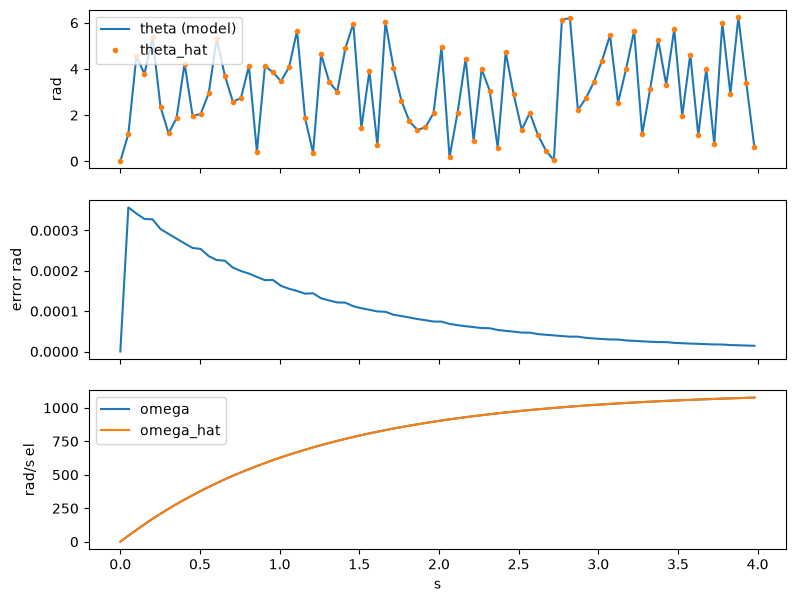

In [5]:
import matplotlib.pyplot as plt

t = [r[0] for r in rows]
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(9, 7))
axes[0].plot(t, [r[1] for r in rows], label='theta (model)')
axes[0].plot(t, [r[2] for r in rows], '.', label='theta_hat')
axes[0].set_ylabel('rad'); axes[0].legend()
axes[1].plot(t, [r[3] for r in rows]); axes[1].set_ylabel('error rad')
axes[2].plot(t, [r[4] for r in rows], label='omega')
axes[2].plot(t, [r[5] for r in rows], label='omega_hat')
axes[2].set_ylabel('rad/s el'); axes[2].set_xlabel('s'); axes[2].legend()
plt.show()

The window since the last take: means and deviations per field, the innovation's autocorrelation for the whiteness test, the peak current.

In [6]:
w = drive.window()
print('n', w['n'], 'i_peak', w['i_peak'])
for name, f in w['fields'].items():
    print('%-4s n %-7s mean %s sd %s' % (name, f['n'], f['mean'], f['sd']))
print('rho', [round(r, 4) for r in w['rho']])

n 240392 i_peak 0.06
id   n 240392  mean 0.0 sd 0.02
iq   n 240392  mean 0.0 sd 0.02
vd   n 240392  mean 0.0 sd 0.01
vq   n 240392  mean 0.0 sd 0.01
eps  n 120196  mean 0.0 sd 0.0
ih   n 120196  mean 0.0 sd 0.014142135623730949
vdc  n 240392  mean 24.773654937744144 sd 0.003
rho [0.0015, -0.0079, -0.0068, 0.0072, -0.0038, 0.0014, -0.0076]


## The back-EMF chain

Op 14 answers a second observer, running beside the loop on the same samples: `drive_observer.c`, the pair `foc_montecarlo.ipynb` ranked first over the drawn plants - a dual flux model with a PLL below 800 rad/s electrical, a leaking flux integrator with its lag put back above 3000, blended on the unit vectors between. It drives nothing. It is a second answer to the angle, from different arithmetic, so the loop's estimate can be checked without a shaft sensor.

The chain reads `v - R i`. A rotor at rest makes no back-EMF, so `valid` is false below the leak's corner, and down there the injection is the only thing that knows where the rotor is.

In [7]:
drive.model_reset()
drive.model_param(j=2e-5, b=6e-5, load=0.0, noise=0.0)
drive.setpoint(id_ref=0.0, iq_ref=0.05, theta=0.0, omega_target=0.0)
drive.mode('sensorless')
chain = []
for iq in (0.05, 0.15, 0.35, 0.60):
    drive.setpoint(iq_ref=iq)
    settle = time.monotonic() + 3.0        # the rotor's j/b is 0.33 s
    while time.monotonic() < settle:
        drive.observers()
        time.sleep(0.02)
    t0 = time.monotonic()
    while time.monotonic() - t0 < 1.5:
        o = drive.observers()
        m = drive.model()
        chain.append((m['omega'], o['error'], m['error'], o['blend'],
                      o['lambda_hat'], o['valid']))
        time.sleep(0.02)
last = drive.observers()
drive.off()
print({k: last[k] for k in ('valid', 'blend', 'blend_lo', 'blend_hi', 'wc')})

{'valid': True, 'blend': 0.35704722427181973, 'blend_lo': 800.0, 'blend_hi': 3000.0, 'wc': 20.0}


`o['error']` is the chain minus the loop's estimate, both out of ONE reply. The rotor's true angle is in another, and at 4000 rad/s electrical a 15 ms round trip is 60 radians - which is why the two columns below are read from the replies that carry them, not differenced across the link.

Four torque currents, each let settle before it is sampled: the speeds they hold span the hand-over, so the table below is the blend crossing from one observer to the other rather than one operating point four times.

In [8]:
import math

def wrap(a):
    return (a + math.pi) % (2.0 * math.pi) - math.pi

def rms_deg(v):
    return math.degrees(math.sqrt(sum(e * e for e in v) / len(v)))

pp = drive.params()['motor_pole_pairs'] or 1
edges = [0.0, 500.0, 1200.0, 2500.0, 1e9]
print('%10s %8s %5s %11s %13s %7s'
      % ('rad/s el', 'rpm', 'n', 'loop deg', 'chain-loop deg', 'blend'))
for lo, hi in zip(edges, edges[1:]):
    band = [r for r in chain if lo <= abs(r[0]) < hi]
    if not band:
        continue
    speed = sum(abs(r[0]) for r in band) / len(band)
    print('%10.0f %8.0f %5d %11.2f %13.2f %7.2f'
          % (speed, speed / pp * 60.0 / math.tau, len(band),
             rms_deg([wrap(r[2]) for r in band]),
             rms_deg([wrap(r[1]) for r in band]),
             sum(r[3] for r in band) / len(band)))
print('lambda   %.5f V.s carried, %.5f in the record'
      % (last['lambda_hat'], drive.params()['motor_lambda_uvs']))

  rad/s el      rpm     n    loop deg chain-loop deg   blend
       277      377    63        0.00          1.85    0.00
       695      949    62        0.00          8.27    0.00
      1417     1933   124        0.00         29.28    0.28
lambda   0.00707 V.s carried, 0.00500 in the record


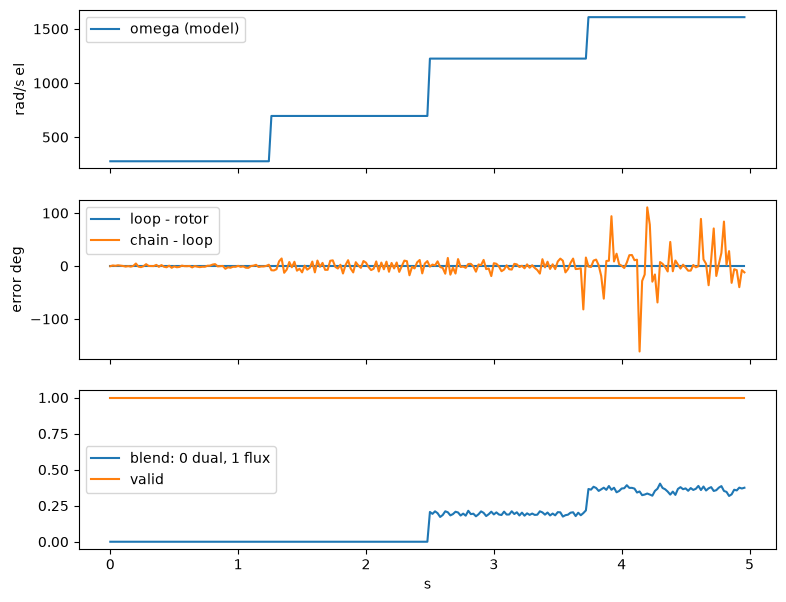

In [9]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(9, 7))
t = [i * 0.02 for i in range(len(chain))]
axes[0].plot(t, [r[0] for r in chain], label='omega (model)')
axes[0].set_ylabel('rad/s el'); axes[0].legend()
axes[1].plot(t, [math.degrees(wrap(r[2])) for r in chain], label='loop - rotor')
axes[1].plot(t, [math.degrees(wrap(r[1])) for r in chain], label='chain - loop')
axes[1].set_ylabel('error deg'); axes[1].legend()
axes[2].plot(t, [r[3] for r in chain], label='blend: 0 dual, 1 flux')
axes[2].plot(t, [1.0 if r[5] else 0.0 for r in chain], label='valid')
axes[2].set_xlabel('s'); axes[2].legend()
plt.show()

In [10]:
drive.model_reset()
drive.source('adc')
device.close()

## Conclusions

In [11]:
import math

errors = [abs(r[3]) for r in rows]
rms = math.sqrt(sum(e * e for e in errors) / len(errors))
print('rotor            %.1f to %.1f rad/s electrical'
      % (min(r[4] for r in rows), max(r[4] for r in rows)))
print('observer error   %.4f rad rms, worst %.4f rad (%.2f deg)'
      % (rms, max(errors), math.degrees(max(errors))))
print('period           %.1f us, %d cycles a period at %.0f MHz'
      % (state['ts'] * 1e6, state['isr_cycles_max'], 475.0))
print('exit             %d TIM1 ticks past the trigger, of %d in a period'
      % (state['exit_ticks_max'], 2 * 2375))
print('virtual step     sample %d, law %d, advance %d cycles'
      % (state['cycles']['sample'], state['cycles']['step'], state['cycles']['advance']))
print('window           %d periods, i_peak %.3f A' % (w['n'], w['i_peak']))
held = [abs(wrap(r[1])) for r in chain if r[5]]
print('chain            %.2f deg rms from the loop where it is valid, %d of %d'
      % (rms_deg(held) if held else float('nan'), len(held), len(chain)))
print('hand-over        dual below %.0f rad/s, flux above %.0f, blended between'
      % (last['blend_lo'], last['blend_hi']))

rotor            0.0 to 1076.3 rad/s electrical
observer error   0.0001 rad rms, worst 0.0004 rad (0.02 deg)
period           20.0 us, 1620 cycles a period at 475 MHz
exit             2921 TIM1 ticks past the trigger, of 4750 in a period
virtual step     sample 610, law 1690, advance 620 cycles
window           240392 periods, i_peak 0.060 A
chain            21.09 deg rms from the loop where it is valid, 249 of 249
hand-over        dual below 800 rad/s, flux above 3000, blended between


Device 10 has two sample sources. On the converters the law reads the injected triple; on the model it reads a PMSM the firmware steps in the same interrupt, so it runs with the AFE off, no stage, and a rotor whose true angle is known - the only way the observer's error can be measured at all.

`theta_hat` and the model's `theta` ride one reply: two requests are 15 ms apart, six radians at 440 rad/s, so an error across two round trips would be the link's.

At -O0 with the caches off a step was 10 040 cycles, 21 us against a 20 us period, and the interrupt outgrew it. With the instruction cache on and -O2 it is 6 756, and the board steps at 2 922 cycles a period with the drivers unpowered (FINDINGS, *The caches were off*).

`rho` is the innovation's autocorrelation: a residual that is not white is a model that is wrong, and `ljung_box` judges it.

The chain is arithmetic this board already has. There is no phase-voltage sense on this hardware, so the voltage it integrates is the commanded duty against the measured DC link, and the current is the three phase channels at 3.2 mA a count. Its `lambda_hat` is the magnitude the flux model carries, which is the one quantity here that sees the magnets - the NTC is on the PCB and the rotor is across an air gap.

Against the stand-in the chain answers off the stand-in's own rotor, so its error column is zero by construction; the C runs on the board. `test_drive_core.py` holds that C to the Python it was ported from, over plants drawn with the Monte Carlo's own tolerances.